# 11장 실습 — 시스템 식별과 도메인 랜덤화

9장은 현장 시연 16판으로 배포의 바닥을 걷어 냈다. 이 노트북은 현장 **시연**이 없을 때를 다룬다. 가진 것은 둘이다 — 시뮬레이터, 그리고 현장에서 전문가가 조작한 **기록 다섯 판**(관측과 명령의 시계열)이다. 기록은 학습 데이터로 쓰지 않는다.

시뮬레이터를 현장에 가깝게 만드는 두 길을 맞세운다.

1. **시스템 식별** — 기록 다섯 판에 가장 잘 맞는 시뮬레이터 매개변수(관측 편향, 제어 지연, 마찰)를 찾는다. 그 시뮬레이터에서 시연을 모은다
2. **도메인 랜덤화** — 매개변수를 하나로 정하지 않고 범위에서 뽑으며 시연을 모은다. 범위를 좁게 잡는 것과 넓게 잡는 것을 따로 잰다

모든 방법은 **같은 예산** — 시뮬레이터 시연 128판을 6장의 데이터셋에 더하는 것 — 을 쓴다. 평가는 세 조건에서 한다. 명목, 실기 대역(배포), 그리고 **다른 현장** — 편향 방향이 반대이고 지연이 두 주기, 마찰이 0.6인 조건이다.

끝에서 `gap/sysid.json` 과 `policy/sim2real_v1.pt` 를 남긴다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import copy

SIG = .22


def dart_eps(count, seed, n=32, cond=None, sig=SIG):
    """잡음 주입 시연을 판 단위로 모은다 (cond: 그 조건의 셀)"""
    rng = np.random.default_rng(seed)
    env = Pert(n, seed, **COND[cond]) if cond else Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, sig, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        dn = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(dn):
            out.append(cur[i])
            cur[i] = []
    out = out[:count]
    X = np.array([a for e in out for a, _ in e], np.float32)
    Y = np.array([b for e in out for _, b in e], np.float32)
    return X, Y, np.array([len(e) for e in out])


def load_cell(path="data/cell_v1"):
    """6장의 데이터셋을 읽는다 — 없으면 같은 설정으로 모은다"""
    f = f"{path}/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        t = pq.read_table(f)
        flat = lambda c: np.asarray(t[c].combine_chunks().flatten())
        X = flat("observation.state").reshape(-1, 10)
        X = X.astype(np.float32)
        Y = flat("action").reshape(-1, 2).astype(np.float32)
        st = json.load(open(f"{path}/meta/stats.json"))
        st = st["observation.state"]
        print(f"{path} 를 읽었다 — {len(X):,} 스텝")
        return X, Y, st
    X, Y, _ = dart_eps(128, seed=1)
    z = X[:, :8] / 10.
    st = {"method": "평균·표준편차", "mean": z.mean(0).tolist(),
          "std": (z.std(0) + 1e-8).tolist()}
    print(f"{path} 가 없다 — 잡음 주입 시연 128판을 모았다")
    return X, Y, st


XS, YS, STATS = load_cell()
MU = np.array(STATS["mean"], np.float32) * 10.   # 셀 척도로
SD = np.array(STATS["std"], np.float32) * 10.


def nz(o):
    """4장의 정규화 — 위치·속도 여덟 차원만 평균·표준편차로"""
    o = o.copy()
    o[:, :8] = (o[:, :8] - MU) / SD
    return o.astype(np.float32)


def pol(net):
    """정규화한 관측으로 평균 행동을 낸다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(nz(env.obs()))).numpy()
    return f


def cycle(rows):
    """성공한 판의 주기 중앙값 (스텝)"""
    st = [r[6] for r in rows if r[4]]
    return float(np.median(st)) if st else float("nan")

data/cell_v1 를 읽었다 — 5,792 스텝


## 현장 기록 다섯 판

실기 대역(배포 조건)에서 전문가가 조작한 다섯 판을 기록한다. 기록에 남는 것은 로봇이 실제로 볼 수 있는 것뿐이다.

- **부품 위치** — 카메라가 본 위치. 편향이 섞여 있다
- **밀대 위치와 속도, 부품 속도** — 편향 없음
- **명령** — 전문가가 낸 명령. 지연을 거쳐 실행된다

적재함 목표는 과제가 정한 것이므로 알고 있다. 참 매개변수는 기록에 없다.

In [8]:
TRUE = COND["배포"]


def field_logs(k=5, seed=21):
    env = Pert(k, seed, **TRUE)
    g = env.g.copy()
    logs = [[] for _ in range(k)]
    done = np.zeros(k, bool)
    for t in range(60):
        o = env.obs()
        a = servo(env)           # 사람 조작자는 참 상태를 본다
        for i in range(k):
            if not done[i]:
                b = g[i] - o[i, 0:2] / 10.    # 카메라가 본 부품
                logs[i].append(dict(b=b, p=b - o[i, 4:6] / 10.,
                                    vb=o[i, 2:4] / 10.,
                                    vp=o[i, 6:8] / 10.,
                                    a=a[i].copy()))
        done |= env.step(a)[1] > 0
    return logs


LOGS = field_logs()
print("기록 길이:", [len(l) for l in LOGS], "스텝")

기록 길이: [54, 59, 49, 56, 57] 스텝


## 시스템 식별

매개변수 후보마다 시뮬레이터로 기록을 **짧게 다시 그린다.** 기록의 5스텝마다, 그 시점의 관측으로 시뮬레이터 상태를 맞추고(부품 위치에서는 편향 후보를 뺀다), 기록된 명령을 지연 후보만큼 늦춰 5스텝을 굴린다. 예측과 기록의 부품·밀대 위치 제곱 오차를 판마다 평균해 다섯 판에 걸쳐 더한 것이 그 후보의 점수다.

긴 궤적을 한 번에 다시 그리지 않는 것은 접촉이 있는 밀기가 조금만 달라도 크게 벌어지기 때문이다. 짧게 끊어 다시 맞추면 그 벌어짐을 피한다.

후보는 지연 0·1·2주기, 마찰 0.5~1.0(0.1 간격), 편향 x·y 각각 −10~10 mm(2 mm 간격)의 격자, 모두 2,178개다.

In [9]:
MODELS = {}


def model(mu):
    if mu not in MODELS:
        xml = XML.replace('friction=".6', f'friction="{mu}')
        MODELS[mu] = mujoco.MjModel.from_xml_string(xml)
    return MODELS[mu]


def seg_err(log, bias, lat, mu, H=5):
    m = model(mu)
    d = mujoco.MjData(m)
    sub = int(round(1 / 20 / m.opt.timestep))
    err, n = 0., 0
    for s in range(lat, len(log) - H, H):
        mujoco.mj_resetData(m, d)
        r = log[s]
        d.qpos[0:2] = r["b"] - bias
        d.qpos[2] = .031
        d.qpos[7:9] = r["p"]
        d.qvel[0:2], d.qvel[6:8] = r["vb"], r["vp"]
        mujoco.mj_forward(m, d)
        for h in range(H):
            j = s + h - lat
            a = log[j]["a"] if j >= 0 else np.zeros(2)
            d.ctrl[:] = np.clip(a, -1, 1) * AMAX
            for _ in range(sub):
                mujoco.mj_step(m, d)
            q = log[s + h + 1]
            err += np.sum((d.qpos[0:2] + bias - q["b"]) ** 2)
            err += np.sum((d.qpos[7:9] - q["p"]) ** 2)
            n += 1
    return err / n


GRID = [(lat, mu, round(bx, 3), round(by, 3))
        for lat in (0, 1, 2) for mu in (.5, .6, .7, .8, .9, 1.)
        for bx in np.arange(-.01, .0101, .002)
        for by in np.arange(-.01, .0101, .002)]
t0 = time.time()
ERR = {c: sum(seg_err(l, np.array(c[2:]), c[0], c[1]) for l in LOGS)
       for c in GRID}
best = min(ERR, key=ERR.get)
print(f"후보 {len(GRID):,}개 ({time.time() - t0:.0f}s)\n")
print(pad("", 10) + pad("식별", 16, True) + pad("참값", 16, True))
print(pad("지연", 10) + pad(f"{best[0]}주기", 16, True)
      + pad(f"{TRUE['lat']}주기", 16, True))
print(pad("마찰", 10) + pad(f"{best[1]:.1f}", 16, True)
      + pad(f"{TRUE['mu']:.1f}", 16, True))
print(pad("편향 mm", 10)
      + pad(f"({best[2] * 1e3:.0f}, {best[3] * 1e3:.0f})", 16, True)
      + pad(f"({TRUE['bias'][0] * 1e3:.0f}, "
            f"{TRUE['bias'][1] * 1e3:.0f})", 16, True))

후보 2,178개 (88s)

                      식별            참값
지연                 1주기           1주기
마찰                   1.0             0.8
편향 mm            (6, -2)         (6, -4)


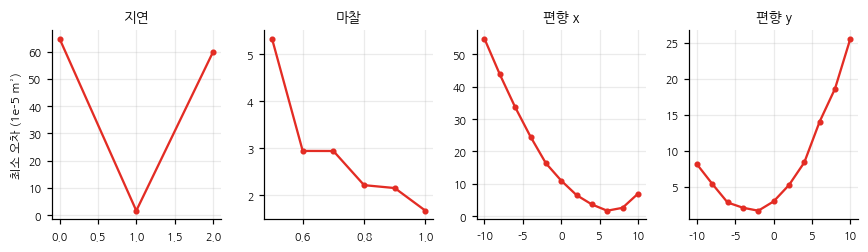

지연     최대/최소 오차 비   38.8
마찰     최대/최소 오차 비    3.2
편향 x   최대/최소 오차 비   32.9
편향 y   최대/최소 오차 비   15.3


In [10]:
PROF = {}
for k, idx, vals in (("지연", 0, (0, 1, 2)),
                     ("마찰", 1, (.5, .6, .7, .8, .9, 1.)),
                     ("편향 x", 2, None), ("편향 y", 3, None)):
    vals = vals or sorted({c[idx] for c in GRID})
    PROF[k] = (vals, [min(e for c, e in ERR.items() if c[idx] == v)
                      for v in vals])

fig, axs = plt.subplots(1, 4, figsize=(8.0, 2.4))
for a, (k, (vals, es)) in zip(axs, PROF.items()):
    xs = [v * 1e3 if "편향" in k else v for v in vals]
    a.plot(xs, np.array(es) * 1e5, "-o", color=RED, ms=3)
    a.set_title(k, fontsize=9)
    a.tick_params(labelsize=7)
axs[0].set_ylabel("최소 오차 (1e-5 m²)", fontsize=8)
plt.tight_layout()
plt.show()
for k, (vals, es) in PROF.items():
    spread = max(es) / min(es)
    print(f"{pad(k, 8)} 최대/최소 오차 비 {spread:6.1f}")

## 같은 예산, 다섯 시뮬레이터

6장의 데이터셋(명목 조건 128판)에 시뮬레이터 시연 128판을 더한다. 더하는 128판을 어느 시뮬레이터에서 모으느냐만 다르다.

| 방법 | 더하는 128판을 모은 시뮬레이터 |
|---|---|
| 명목만 | 더하지 않는다 (128판) |
| 식별 | 위에서 식별한 매개변수 하나 |
| 좁은 랜덤화 | 식별값 주위 — 편향 ±4 mm, 지연은 식별값, 마찰 0.7~1.0 |
| 넓은 랜덤화 | 편향 ±15 mm, 지연 0~3주기, 마찰 0.3~1.5 |
| 신탁 | 배포 조건의 참 매개변수 |

신탁은 현장을 완벽하게 안다는 가정의 상한이다. 평가 조건 **다른 현장**은 편향 (−6, 4) mm, 지연 2주기, 마찰 0.6이다 — 식별한 현장과 다른 현장에 정책을 옮기는 상황이다.

In [11]:
COND["다른 현장"] = dict(bias=(-.006, .004), lat=2, mu=.6)
EVC = ["명목", "배포", "다른 현장"]
IDENT = dict(bias=best[2:], lat=best[0], mu=best[1])


def sim_demos(count, draw, seed, n=8):
    """draw(rng) 가 준 매개변수의 셀에서 잡음 주입 시연을 모은다"""
    r = np.random.default_rng(seed)
    X, Y, got, grp = [], [], 0, 0
    while got < count:
        env = Pert(n, seed * 100 + grp, **draw(r))
        grp += 1
        cur = [[] for _ in range(n)]
        k = 0
        while k < n and got < count:
            o = env.obs()
            lab = servo(env)
            act = np.clip(lab + r.normal(0, SIG, lab.shape), -1, 1)
            for i in range(n):
                cur[i].append((o[i], lab[i]))
            dn = env.step(act.astype(np.float32))[1]
            for i in np.flatnonzero(dn):
                if got < count:
                    X += [a for a, _ in cur[i]]
                    Y += [b for _, b in cur[i]]
                    got += 1
                    k += 1
                cur[i] = []
    return np.array(X, np.float32), np.array(Y, np.float32)


def narrow(r):
    b = np.array(IDENT["bias"]) + r.uniform(-.004, .004, 2)
    return dict(bias=tuple(b), lat=IDENT["lat"],
                mu=float(r.uniform(.7, 1.)))


def wide(r):
    return dict(bias=tuple(r.uniform(-.015, .015, 2)),
                lat=int(r.integers(0, 4)),
                mu=float(r.uniform(.3, 1.5)))


METHODS = {"명목만": None, "식별": lambda r: IDENT,
           "좁은 랜덤화": narrow, "넓은 랜덤화": wide,
           "신탁": lambda r: TRUE}
SEEDS = (0, 1, 2)
EV = dict(n=100, reps=2)
SC, NETS, LOG = {}, {}, []
t0 = time.time()
for k, draw in METHODS.items():
    X, Y = XS, YS
    if draw is not None:
        Xd, Yd = sim_demos(128, draw, seed=5)
        X, Y = np.concatenate([XS, Xd]), np.concatenate([YS, Yd])
    for s in SEEDS:
        net = bc(nz(X), Y, seed=s)
        NETS[(k, s)] = net
        for c in EVC:
            rows = rollout(pol(net), c, tag=s, ver=f"s2r-{k}", **EV)
            LOG.extend(rows)
            SC.setdefault((k, c), []).append(rate(rows))
    print(f"  {k} 끝  ({time.time() - t0:.0f}s)", flush=True)

print()
print(pad("방법", 14) + "".join(pad(c, 20, True) for c in EVC))
for k in METHODS:
    cells = [f"{np.mean(SC[(k, c)]):.3f} "
             f"[{min(SC[(k, c)]):.2f}, {max(SC[(k, c)]):.2f}]"
             for c in EVC]
    print(pad(k, 14) + "".join(pad(x, 20, True) for x in cells))

  명목만 끝  (51s)


  식별 끝  (103s)


  좁은 랜덤화 끝  (154s)


  넓은 랜덤화 끝  (208s)


  신탁 끝  (259s)



방법                          명목                배포           다른 현장
명목만          1.000 [1.00, 1.00]  0.936 [0.89, 0.97]  0.471 [0.44, 0.53]
식별            0.993 [0.98, 1.00]  1.000 [1.00, 1.00]  0.553 [0.44, 0.65]
좁은 랜덤화     1.000 [1.00, 1.00]  0.995 [0.99, 1.00]  0.151 [0.12, 0.17]
넓은 랜덤화     0.715 [0.50, 0.90]  0.938 [0.82, 1.00]  0.623 [0.48, 0.86]
신탁            1.000 [1.00, 1.00]  1.000 [1.00, 1.00]  0.339 [0.22, 0.44]


## 식별 정책을 남긴다

규칙을 코드로 적는다. 신탁을 뺀 방법 가운데 **실기 대역(배포)에서 가장 높고, 명목에서 0.99 이상인 것**을 고른다. 다른 현장은 규칙에 넣지 않는다 — 다른 현장에서의 성적은 12장이 따로 다룬다.

In [12]:
cand = [k for k in METHODS if k != "신탁"
        and np.mean(SC[(k, "명목")]) >= .99] or ["명목만"]
pick = max(cand, key=lambda k: np.mean(SC[(k, "배포")]))
os.makedirs("gap", exist_ok=True)
os.makedirs("policy", exist_ok=True)
torch.save(NETS[(pick, 0)], "policy/sim2real_v1.pt")
OUT = {"identified": {"lat": int(best[0]), "mu": float(best[1]),
                      "bias": [float(best[2]), float(best[3])]},
       "true": {"lat": TRUE["lat"], "mu": TRUE["mu"],
                "bias": list(TRUE["bias"])},
       "profile_ratio": {k: round(max(e) / min(e), 1)
                         for k, (v, e) in PROF.items()},
       "pick": pick,
       "scores": {k: {c: round(float(np.mean(SC[(k, c)])), 3)
                      for c in EVC} for k in METHODS}}
with open("gap/sysid.json", "w") as f:
    json.dump(OUT, f, ensure_ascii=False, indent=1)
save_log("report/ch11_log.csv", LOG)
print(f"고른 방법: {pick}")
print()
print("남긴 산출물")
print("  gap/sysid.json         식별값·참값·오차 곡면·방법별 성적")
print("  policy/sim2real_v1.pt  고른 방법의 정책 (시드 0)")
print(f"  report/ch11_log.csv    판별 로그 {len(LOG):,}줄")

고른 방법: 식별

남긴 산출물
  gap/sysid.json         식별값·참값·오차 곡면·방법별 성적
  policy/sim2real_v1.pt  고른 방법의 정책 (시드 0)
  report/ch11_log.csv    판별 로그 14,239줄


## 정리

**기록 다섯 판으로 지연과 편향을 식별했다.** 마찰은 오차 곡면이 평평해 식별되지 않았다.

**식별로 모은 시뮬레이터 시연 128판이 신탁과 같은 성적을 냈다.** 실기 대역에서 1.000이다. 틀린 마찰은 정책이 민감하지 않은 매개변수라 문제가 되지 않았다.

**어느 방법도 다른 현장을 풀지 못했다.** 식별 0.553, 넓은 랜덤화 0.623이 가장 나은 편이고, 좁은 랜덤화는 0.151이다. 한 현장에 맞출수록 다른 현장에서 잃는다.

**고른 것은 식별이다.** `policy/sim2real_v1.pt` 와 식별값을 적은 `gap/sysid.json` 을 남겼다.